<b>¡Hola Edgar!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


# ***Proyecto Final - Análisis de una empresa de Telecomunicaciones***

## Objetivo general: Identificar a los operadores ineficaces de la empresa CallMeMaybe

### ¿Qué hace la empresa CallMeMaybe?
Es una empresa que brinda servicio de telefonía virtual, sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores o realizar llamadas salientes a través de sus operadores. Asimismo, los operadores también pueden realizar llamadas internas para comunicarse entre ellos, estas llamadas se realizan a través de la red de CallMeMaybe.

Actualmente la empresa se encuentra desarrollando una nueva función que tendrá como objetivo brindar a los y las supervisores con información clave para identificar a los operadores menos eficaces.

#### Determinación de aspectos por los que un operador se puede considerar como ineficaz

Considerando el modelo de negocio de CallMeMaybe (servicio de telefonía), podemos identificar los siguientes aspectos para identificar a un operador poco eficaz:
1. Alta cantidad de **llamadas entrantes perdidas** (internas y externas)
2. **Tiempo de espera** prolongado para las llamadas entrantes
3. Número bajo de **llamadas salientes** por parte del operador


### Descripción de los datos
Se cuenta con dos datasets que contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Estos datasets son proporcionados por la misma empresa.

Dataset **`telecom_dataset_us.csv`**; Contiene los datos de operación, identifica a los operadores, indica la información para las llamadas (duración, entrantes o salientes, respondidas o perdidas). 

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

Conjunto de datos **`telecom_clients_us.csv`**; Contiene datos de tarifa y fecha de registro de los clientes.

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

#### Pero, ¿Y el tiempo de espera para las llamadas entrantes?
Los datasets no incluyen esta métrica, sin embargo podemos determinarla mediante la resta las columnas `total_call_duration` - `call_duration` en nuestro dataset **`telecom_dataset_us.csv`**.

Dado que los datasets proporcionados por CallMeMaybe se encuentran en idioma inglés, crearemos una nueva columna dentro de nuestro dataset **`telecom_dataset_us.csv`** con el nombre `waiting_time` que contenga el tiempo de espera.

### Planteamiento del problema

**¿Que se requiere hacer?** Identificar las métricas e indicadores necesarios para evaluar la eficacia de los operadores.

**¿Por qué medir el desempeño de un colaborador?**

*"Lo que no se define no se puede medir. Lo que no se mide, no se puede mejorar"*

Para toda empresa o negocio siempre se recomienda la identificación y medición el desempeño de los colaboradores (en este caso, operadores). Para CallMeMaybe, la medición del desempeño pudiera arrojar como salientes los siguientes aspectos:
- Desempeño como tal de los operadores (incluso un historial si la medición se realiza de manera contínua)
- Posible relación entre el desempeño operacional y los ingresos de la empresa
- Identificación de oportunidades de mejora tanto para el personal como para la operación misma
- Observar falta de recursos (humano, infraestructura, software/hardware, entre otros)
- Situaciónes en las que el desempeño aumente o disminuya

### 1. Preparación de Entorno y Visualización de Datos

**Descripción:** Esta sección tiene el objetivo de importar las librerías necesarias para el análisis, carga de los dataset y su correcta visualización. Esta visualización es útil como base para la siguiente sección de Análisis exploratorio de datos (EDA).

#### 1.1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import math as mth
from math import factorial
from scipy import stats as st
import matplotlib.dates as mdates
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

#### 1.2. Carga y unión de datasets
Se cargarán ambos datasets y se unirán por la columna `user_id`.

In [2]:
telecom_datasets = pd.read_csv('/datasets/telecom_dataset_us.csv')
telecom_clients = pd.read_csv('/datasets/telecom_clients_us.csv')
data = telecom_datasets.merge(telecom_clients, on = 'user_id', how = 'left')

#### 1.3. Visualización inicial de datos por info(), describe, head(), etc.

In [3]:
data.info()
print()
print(data.describe)
print()
data.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
 9   tariff_plan          53902 non-null  object 
 10  date_start           53902 non-null  object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 4.6+ MB

<bound method NDFrame.describe of        user_id                       date direction internal  operator_id  \
0       166377  2019-08-04 00:00:00+03:00        in    Fal

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,B,2019-08-01


<div class="alert alert-block alert-success">
<b>Celda [3]</b> <a class="tocSkip"></a><br>
Has realizado un buen trabajo al explorar inicialmente el conjunto de datos. La utilización de `data.info()` y `data.describe()` proporciona una visión clara de la estructura y las características estadísticas de los datos. Esto es crucial para identificar problemas potenciales desde el principio, como valores faltantes o tipos de datos incorrectos, que podrían afectar el análisis posterior.
</div>


### 2. Análisis Exploratorio de Datos (EDA)

#### 2.1. Preprocesamiento de Datos

Se realizó un preprocesamiento en Visual Studio Code de ambos datasets.

Se tienen observaciones para el dataset **`telecom_dataset_us.csv`**:
1. Para la columna `internal` se encontaron valores nulos - Se imputarán con el texto 'S/D' (sin dato), no es una clave fundamental para este análisis.
2. Para la columna `operator_id` se encontaron valores nulos - Se eliminarán, dado que `operator_id` es una clave fundamental para este análisis y al no tenerlo el resto de la fila pierde su utilidad.
3. Se encontaron entradas repeditas en el dataset - Se eliminarán para proteger la integridad de los datos, dado que las entradas repetidas pueden alterar el análisis o generar sesgo.
4. Duración de llamadas por la columna `call_duration`: Se observó un numero considerable de llamadas con duración 0. Estos datos pueden ser válidos porque aunque `call_duration` sea cero, la columna `total_call_duration` puede sí tener una duración, lo cual indicaría que la llamada estuvo en espera pero no fue atentida por un operador, esto también nos lleva a relacionarla con la columna `is_missed_call`, la cual probablemente se encuentre como 'True' para las llamadas que tienen 0 en `call_duration`. Por todo lo anterior se considera que estos datos son válidos y no requieren de un tratamiento especial.
5. Para las columnas con **variables numéricas** `calls_count`, `call_duration`, `total_call_duration` y `waiting_time` (columna que crearemos) pueden encontrarse valores atípicos, los cuales no serán considerados si se encuentran dentro del percentil 99.

**Importante:** Si durante el análisis se llegara a detectar cualquier otro aspecto crítico, se analizará debidamente con el objetivo de evitar cualquier sesgo de información o alteración del análisis.

#### 2.2. Renombramiento de columnas
Partiendo de la visualización, evaluar si los nombres de las columnas de nuestros datasets requieren de renombramiento, en caso de no ser claras, no sean lo suficientemente significativas, etc.

**Obervaciones:** Los nombres de las columnas tienen una redacción correcta (minúsculas, sin espacios, etc.), además de que se cuenta con la descripción clara de cada una.

#### 2.3. Conversión de tipo de datos
Partiendo de la visualización, realizar la conversión de tipo de datos necesaria para aquellas columnas que alberguen datos en un tipo incorrecto. Por ejemplo, una columna que albergue fechas pero se encuentre en formato object, números albergados como tipo texto, etc.

In [4]:
data['user_id'] = data['user_id'].astype('string')
data['date'] = pd.to_datetime(data['date'], format = '%Y-%m-%d %H:%M:%S')
data['operator_id'] = data['operator_id'].astype('string')
data['operator_id'] = data['operator_id'].str.replace(r'\.0$', '', regex=True)
data['date_start'] = pd.to_datetime(data['date_start'], format = '%Y-%m-%d')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  string                               
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  object                               
 3   internal             53785 non-null  object                               
 4   operator_id          45730 non-null  string                               
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
 9   tariff

<div class="alert alert-block alert-warning">
<b>Celda [4]</b> <a class="tocSkip"></a><br>
Aunque has convertido el campo 'date' a un formato de fecha y hora, es importante asegurarse de que todas las conversiones de tipos de datos sean necesarias para el análisis que planeas realizar. Por ejemplo, si no vas a realizar análisis temporales detallados, podrías reconsiderar la conversión de columnas que no se utilizarán en dicho contexto. Esto optimiza el uso de memoria y procesamiento.
</div>


#### 2.4. Identificación y procesamiento de valores ausentes
Partiendo de la visualización, se identificarán y contarán los valores ausentes por medio de las funciones apropiadas (recordar estrategia en sección 2.1).

In [5]:
print(data.isna().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
tariff_plan               0
date_start                0
dtype: int64


In [6]:
data['internal'] = data['internal'].fillna('S/D')
data = data.dropna(subset = ['operator_id'])
print(data.isna().sum())
print('-'*47)
data.info()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
tariff_plan            0
date_start             0
dtype: int64
-----------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Int64Index: 45730 entries, 1 to 53900
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              45730 non-null  string                               
 1   date                 45730 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            45730 non-null  object                               
 3   internal             45730 non-null  object                               
 4   operator_id          45730 non-null  string                           

<div class="alert alert-block alert-success">
<b>Celda [6]</b> <a class="tocSkip"></a><br>
Has manejado eficazmente los valores faltantes en las columnas 'internal' y 'operator_id'. Utilizar `fillna` para reemplazar valores faltantes y `dropna` para eliminar filas incompletas es una estrategia adecuada para asegurar que los datos sean consistentes y listos para el análisis. Esto también ayuda a evitar errores en etapas posteriores del análisis.
</div>


#### 2.5. Identificación y procesamiento de valores duplicados

Partiendo de la visualización, se identificarán y contarán los valores duplicados por medio de las funciones apropiadas (recordar estrategia en sección 2.1).

In [7]:
print(data.duplicated().sum())

4184


In [8]:
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41546 entries, 1 to 53899
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              41546 non-null  string                               
 1   date                 41546 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            41546 non-null  object                               
 3   internal             41546 non-null  object                               
 4   operator_id          41546 non-null  string                               
 5   is_missed_call       41546 non-null  bool                                 
 6   calls_count          41546 non-null  int64                                
 7   call_duration        41546 non-null  int64                                
 8   total_call_duration  41546 non-null  int64                                
 9   tariff

<div class="alert alert-block alert-warning">
<b>Celda [8]</b> <a class="tocSkip"></a><br>
Has eliminado correctamente los duplicados de tu conjunto de datos, lo cual es crucial para evitar sesgos en el análisis. Sin embargo, es importante entender por qué estos duplicados estaban presentes inicialmente. Su eliminación podría afectar la interpretación de los datos si los duplicados representaban, por ejemplo, eventos válidos que ocurrieron más de una vez.
</div>


#### 2.6. Identificación de Valores atípicos
Calcular los percentiles 95 y 99 para las columnas con variables numéricas (definidas en la sección 2.1).

In [9]:
calls_count_percentil_95 = np.percentile(data['calls_count'], 95)
calls_count_percentil_99 = np.percentile(data['calls_count'], 99)
print(f"Percentil 95 de 'calls_count': {calls_count_percentil_95}")
print(f"Percentil 99 de 'calls_count': {calls_count_percentil_99}")

call_duration_percentil_95 = np.percentile(data['call_duration'], 95)
call_duration_percentil_99 = np.percentile(data['call_duration'], 99)
print(f"Percentil 95 de 'call_duration': {call_duration_percentil_95}")
print(f"Percentil 99 de 'call_duration': {call_duration_percentil_99}")

total_call_duration_percentil_95 = np.percentile(data['total_call_duration'], 95)
total_call_duration_percentil_99 = np.percentile(data['total_call_duration'], 99)
print(f"Percentil 95 de 'total_call_duration': {total_call_duration_percentil_95}")
print(f"Percentil 99 de 'total_call_duration': {total_call_duration_percentil_99}")

Percentil 95 de 'calls_count': 65.0
Percentil 99 de 'calls_count': 165.0
Percentil 95 de 'call_duration': 4161.0
Percentil 99 de 'call_duration': 10982.50000000003
Percentil 95 de 'total_call_duration': 5033.5
Percentil 99 de 'total_call_duration': 13646.35000000005


In [10]:
data = data[(data['calls_count'] <= 165.0) & (data['call_duration'] <= 10982.50) & (data['total_call_duration'] <= 13646.35)]

print("Dimensiones del conjunto de datos sin datos atípicos en variables numéricas:", data.shape)

Dimensiones del conjunto de datos sin datos atípicos en variables numéricas: (40912, 11)


<div class="alert alert-block alert-success">
<b>Celda [10]</b> <a class="tocSkip"></a><br>
Excelente trabajo al identificar y eliminar los datos atípicos utilizando percentiles. Esto ayuda a mantener la integridad del análisis al reducir el impacto de valores extremos que podrían distorsionar los resultados. Asegúrate de que esta limpieza no elimine datos relevantes para el análisis que deseas realizar.
</div>


### 3. Cálculos, recursos gráficos y KPI's
Esta sección se centra en la realización de calculos, visualización de resultados de manera gráfica y el cálculo de los KPI's.

#### 3.1. Creación de la columna 'waiting_time'
Calcula el tiempo de espera para las llamadas entrantes, guárdalo en una nueva columna con el nombre 'waiting_time' dentro del dataset **data**.

In [11]:
data['waiting_time'] = data['total_call_duration'] - data ['call_duration']
data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,waiting_time
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01,8
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020,False,2,3,29,B,2019-08-01,26


In [12]:
waiting_time_percentil_95 = np.percentile(data['waiting_time'], 95)
waiting_time_percentil_99 = np.percentile(data['waiting_time'], 99)
print(f"Percentil 95 de 'waiting_time': {waiting_time_percentil_95}")
print(f"Percentil 99 de 'waiting_time': {waiting_time_percentil_99}")

Percentil 95 de 'waiting_time': 1017.0
Percentil 99 de 'waiting_time': 2095.6699999999983


<div class="alert alert-block alert-warning">
<b>Celda [12]</b> <a class="tocSkip"></a><br>
Al calcular percentiles para 'waiting_time', es importante considerar el contexto de estos valores. Asegúrate de que la eliminación de datos atípicos no esté afectando negativamente la representatividad de tus datos. Esto es crucial para mantener la validez de cualquier conclusión que se derive del análisis.
</div>


In [15]:
data = data[(data['waiting_time'] <= 2095.67)]

print("Dimensiones del conjunto de datos sin datos atípicos en variable calculada 'waiting_time':", data.shape)

Dimensiones del conjunto de datos sin datos atípicos en variable calculada 'waiting_time': (40502, 12)


#### 3.2. Identifica el número de llamadas recibidas por operador.

In [16]:
received_calls_by_operator = data[data['direction'] == 'in']['operator_id'].value_counts()
print(received_calls_by_operator)

908960    108
901880    108
893804    107
901884     95
885890     94
         ... 
940772      1
968520      1
911152      1
958454      1
947612      1
Name: operator_id, Length: 754, dtype: Int64


##### Realiza gráficos.

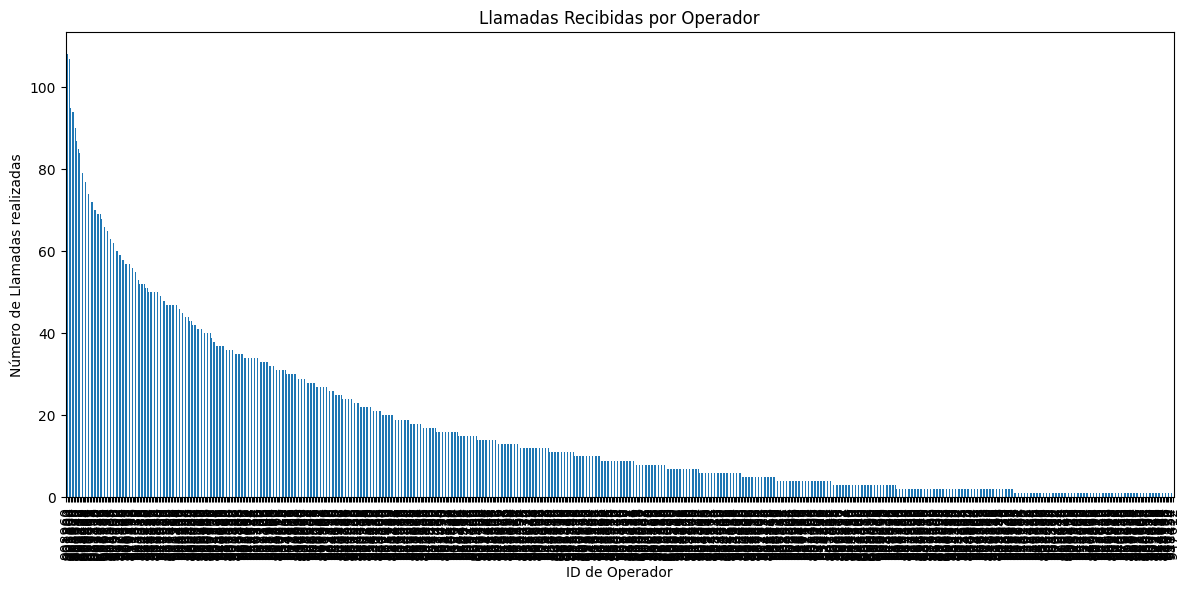

In [17]:
received_calls_by_operator_plot = received_calls_by_operator.plot(kind='bar', figsize=(12, 6))

received_calls_by_operator_plot.set_title('Llamadas Recibidas por Operador')
received_calls_by_operator_plot.set_xlabel('ID de Operador')
received_calls_by_operator_plot.set_ylabel('Número de Llamadas realizadas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Celda [17]</b> <a class="tocSkip"></a><br>
La visualización de las llamadas recibidas por operador es clara y bien estructurada. El uso de gráficos de barras es apropiado para mostrar comparaciones categóricas como esta, ya que facilita la identificación de operadores con mayores volúmenes de llamadas recibidas.
</div>


#### 3.3. Determina el número de llamadas perdidas por operador.

In [18]:
missed_calls_by_operator = data[data['is_missed_call'] == True]['operator_id'].value_counts()
print(missed_calls_by_operator)

891410    119
891414    113
901880    110
893804    110
901884    104
         ... 
924370      1
884402      1
914348      1
942174      1
960674      1
Name: operator_id, Length: 876, dtype: Int64


##### Realiza gráficos.

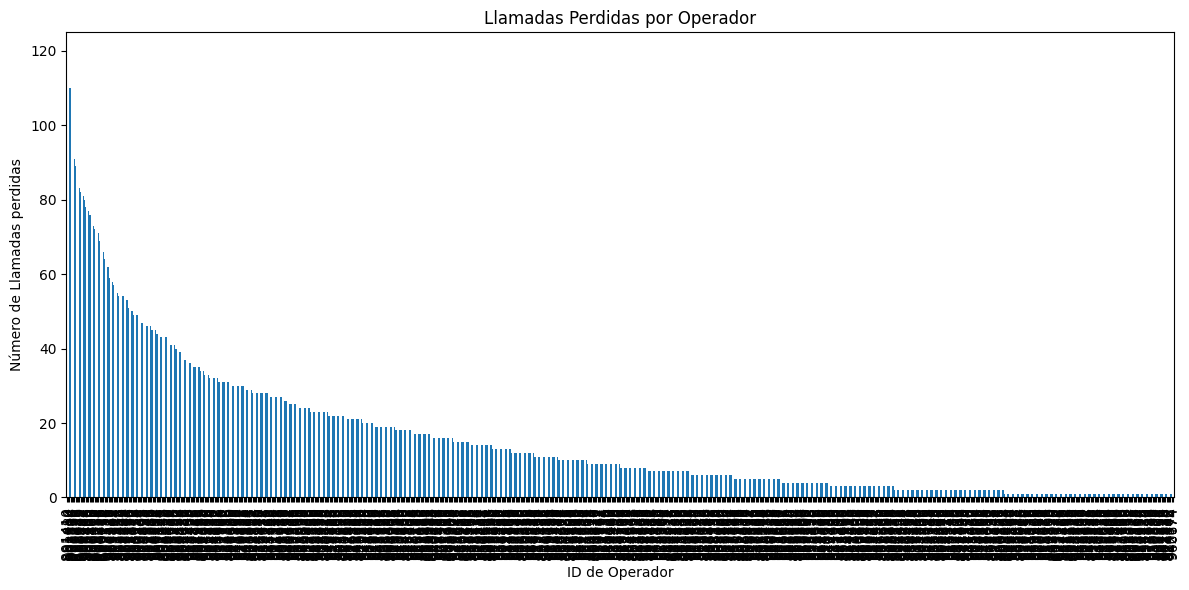

In [19]:
missed_calls_by_operator_plot = missed_calls_by_operator.plot(kind='bar', figsize=(12, 6))

missed_calls_by_operator_plot.set_title('Llamadas Perdidas por Operador')
missed_calls_by_operator_plot.set_xlabel('ID de Operador')
missed_calls_by_operator_plot.set_ylabel('Número de Llamadas perdidas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Celda [19]</b> <a class="tocSkip"></a><br>
Aunque el gráfico de llamadas perdidas por operador es útil, considera agregar una línea de tendencia o resaltar los operadores con el mayor número de llamadas perdidas. Esto mejorará la interpretación visual y ayudará a identificar rápidamente patrones o anomalías significativas.
</div>


#### 3.4. Calcula el promedio del tiempo de espera por operador.

In [20]:
mean_waiting_time_by_operator = data.groupby('operator_id')['waiting_time'].mean().sort_values(ascending = False)
print(mean_waiting_time_by_operator)

operator_id
919162    1631.894737
919362    1594.117647
919364    1565.416667
938070    1561.333333
919504    1517.642857
             ...     
946454       0.000000
955068       0.000000
958458       0.000000
914626       0.000000
960674       0.000000
Name: waiting_time, Length: 1092, dtype: float64


##### Realiza gráficos.

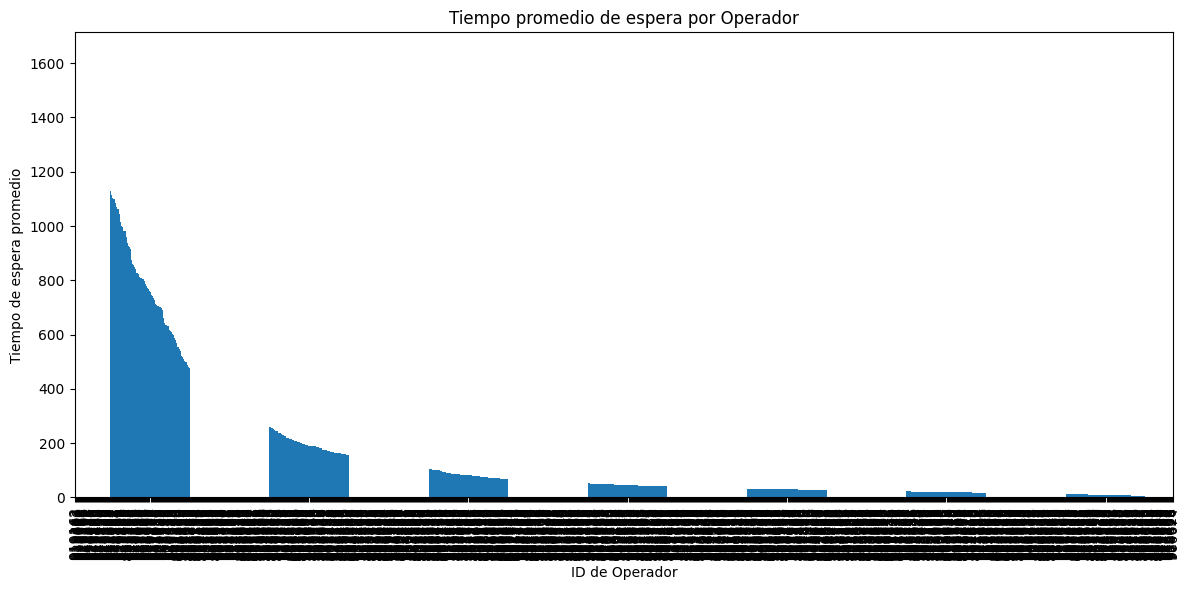

In [21]:
mean_waiting_time_by_operator_plot = mean_waiting_time_by_operator.plot(kind='bar', figsize=(12, 6))

mean_waiting_time_by_operator_plot.set_title('Tiempo promedio de espera por Operador')
mean_waiting_time_by_operator_plot.set_xlabel('ID de Operador')
mean_waiting_time_by_operator_plot.set_ylabel('Tiempo de espera promedio')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 3.5. Calcula el promedio de la duración de llamada sin incluír el tiempo de espera (columna 'call_duration') por operador.

In [22]:
mean_call_duration_by_operator = data.groupby('operator_id')['call_duration'].mean().sort_values(ascending = False)
print(mean_call_duration_by_operator)

operator_id
938070    5647.500000
919362    5060.823529
921574    4353.473684
919482    4038.800000
919162    3961.736842
             ...     
969262       0.000000
937778       0.000000
962904       0.000000
969284       0.000000
905308       0.000000
Name: call_duration, Length: 1092, dtype: float64


##### Realiza gráficos.

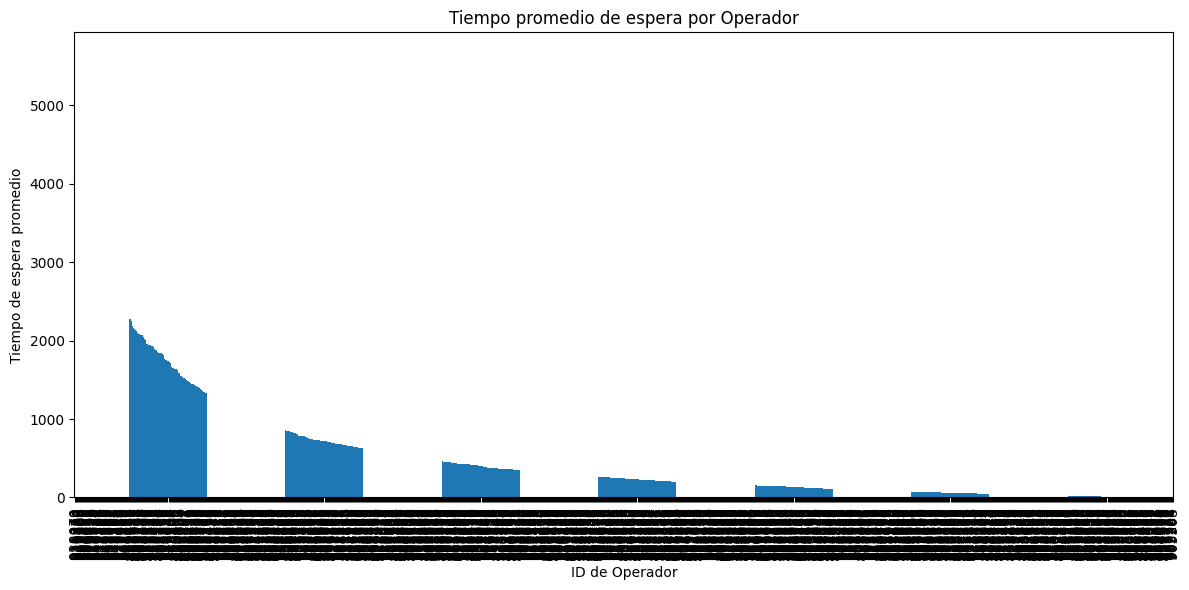

In [23]:
mean_call_duration_by_operator_plot = mean_call_duration_by_operator.plot(kind='bar', figsize=(12, 6))

mean_call_duration_by_operator_plot.set_title('Tiempo promedio de espera por Operador')
mean_call_duration_by_operator_plot.set_xlabel('ID de Operador')
mean_call_duration_by_operator_plot.set_ylabel('Tiempo de espera promedio')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Celda [23]</b> <a class="tocSkip"></a><br>
El título del gráfico en esta celda parece incorrecto, ya que debería referirse al tiempo promedio de duración de la llamada por operador. Asegúrate de que los títulos sean precisos para evitar confusiones y reflejar correctamente el contenido del gráfico.
</div>


#### 3.6. Investiga el comportamiento de los operadores a lo largo del tiempo.
- Analiza las llamadas recibidas, realizadas y perdidas por día para cada operador
- Identifica los horarios en los que haya picos máximos o mínimos de llamadas entrantes

In [24]:
# Análsis de llamadas totales por día
total_by_day = data.groupby('date').agg(
    received_calls=('direction', lambda x: (x == 'in').sum()),
    made_calls=('direction', lambda x: (x == 'out').sum()),
    missed_calls=('is_missed_call', 'sum')
)

print(total_by_day)

                           received_calls  made_calls  missed_calls
date                                                               
2019-08-02 00:00:00+03:00               0           6             3
2019-08-03 00:00:00+03:00               1           5             2
2019-08-04 00:00:00+03:00               0           3             2
2019-08-05 00:00:00+03:00               2          11             6
2019-08-06 00:00:00+03:00               2          13             7
...                                   ...         ...           ...
2019-11-24 00:00:00+03:00              86         119            61
2019-11-25 00:00:00+03:00             298         674           328
2019-11-26 00:00:00+03:00             271         630           289
2019-11-27 00:00:00+03:00             299         665           316
2019-11-28 00:00:00+03:00             283         667           315

[118 rows x 3 columns]


##### Realiza gráficos.

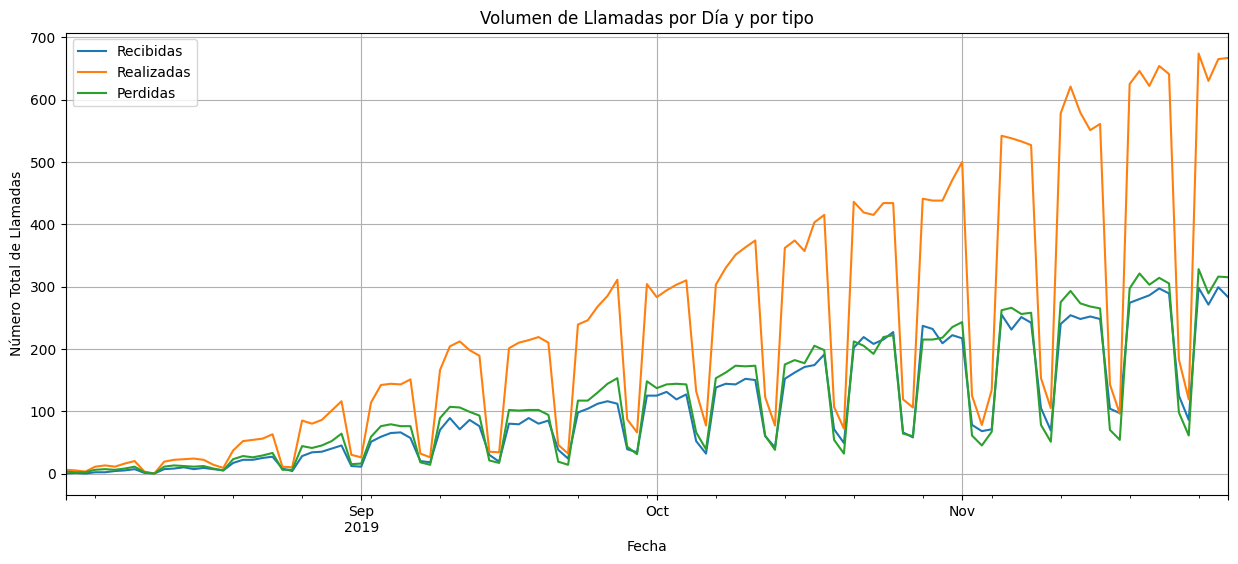

In [25]:
# Llamadas por día y por tipo
start_date = data['date'].min()
end_date = data['date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

complete_total_by_day = total_by_day.reindex(date_range, fill_value=0)

complete_total_by_day.plot(figsize=(15, 6))

plt.title('Volumen de Llamadas por Día y por tipo')
plt.xlabel('Fecha')
plt.ylabel('Número Total de Llamadas')
plt.legend(['Recibidas', 'Realizadas', 'Perdidas'])
plt.grid(True)
plt.show()

In [26]:
# Valores de tiempo únicos en la columna 'date'
print(data['date'].dt.time.unique())

[datetime.time(0, 0)]


**Conclusiones relevantes en este punto:**

- **Analiza las llamadas recibidas, realizadas y perdidas por día para cada operador**

  El análisis por operador a lo largo del tiempo no es viable para la visualización. La cantidad de operadores es tan grande que cualquier intento de graficarlos individualmente en un solo gráfico sería inútil.

  Sin embargo, se optó por la aplicación de una alternativa; Analizar los totales por día de llamadas recibidas, realizadas y perdidas, de modo que pudieramos observar como se han comportan con el avance del tiempo.
  
- **Identifica los horarios en los que haya picos máximos o mínimos de llamadas entrantes**

  El análisis de horarios pico no pudo efectuarse. Desafortunadamente, la columna de fecha solo contiene el día y no la hora de la llamada, esto no fue previsto durante la descomposición ni el pre-procesamiento de datos.

#### 3.7. Calcula las métricas de ineficiencia (KPI's)

##### 3.7.1. Calcula la Tasa de llamadas perdidas entrantes

In [27]:
missed_call_rate_by_operator = data.groupby('operator_id').agg(
    total_inbound=('direction', lambda x: (x == 'in').sum()),
    total_missed=('is_missed_call', 'sum')
)

missed_call_rate_by_operator['missed_call_rate'] = (
    missed_call_rate_by_operator['total_missed'] / missed_call_rate_by_operator['total_inbound']
) * 100

print("Tasa de llamadas entrantes perdidas por operador:")
print(missed_call_rate_by_operator)

Tasa de llamadas entrantes perdidas por operador:
             total_inbound  total_missed  missed_call_rate
operator_id                                               
879896                  21            47        223.809524
879898                  57            89        156.140351
880020                   7             6         85.714286
880022                   8            29        362.500000
880026                  18            87        483.333333
...                    ...           ...               ...
972410                   0             2               inf
972412                   1             2        200.000000
972460                   1             3        300.000000
973120                   0             1               inf
973286                   1             0          0.000000

[1092 rows x 3 columns]


<div class="alert alert-block alert-warning">
<b>Celda [27]</b> <a class="tocSkip"></a><br>
La tasa de llamadas perdidas por operador presenta valores infinitos, lo cual indica divisiones por cero. Considera manejar estos casos, quizás excluyendo operadores sin llamadas entrantes, para evitar resultados engañosos en tus análisis y asegurar que las comparaciones sean válidas.
</div>


##### 3.7.2. Calcula el Tiempo promedio de espera

In [28]:
mean_waiting_time_by_operator = data.groupby('operator_id')['waiting_time'].mean()

print("Tiempo promedio de espera por operador:")
print(mean_waiting_time_by_operator)

Tiempo promedio de espera por operador:
operator_id
879896    104.914530
879898    457.696035
880020     14.000000
880022     53.971429
880026    121.978022
             ...    
972410    374.500000
972412    210.000000
972460     88.571429
973120     10.000000
973286     88.000000
Name: waiting_time, Length: 1092, dtype: float64


##### 3.7.3. Calcula la Tasa de llamadas salientes

In [29]:
outgoing_calls_by_operator = data['operator_id'].value_counts()

print("Número total de llamadas por operador:")
print(outgoing_calls_by_operator)

Número total de llamadas por operador:
901884    323
901880    301
893804    289
887276    267
891410    261
         ... 
945898      1
928284      1
905470      1
905082      1
914272      1
Name: operator_id, Length: 1092, dtype: Int64


##### 3.7.4. Genera un gráfico de barras apiladas para ver si ciertos planes tarifarios están asociados con un mayor número de llamadas perdidas o un mayor tiempo de espera.

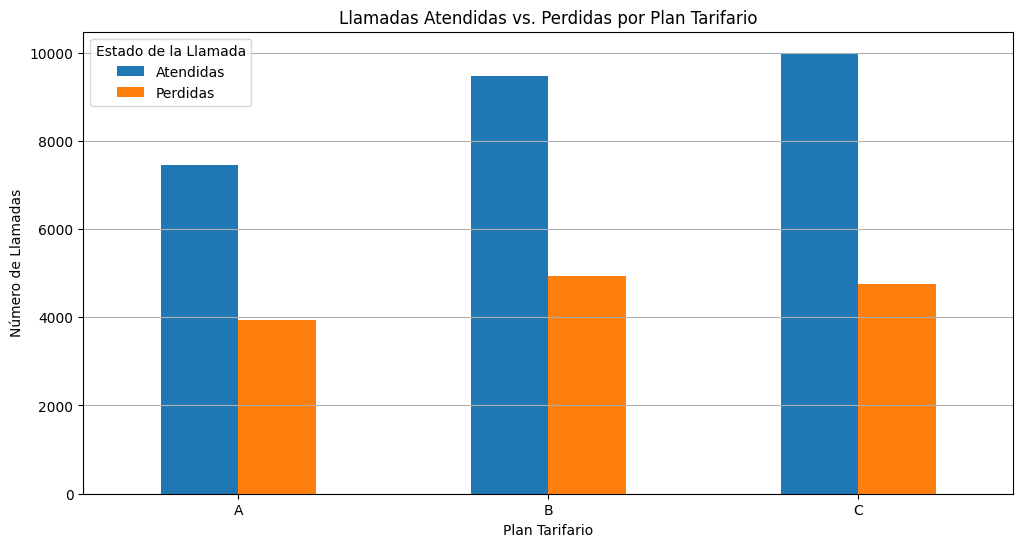

In [30]:
# Gráfico de llamadas perdidas por plan tarifario
missed_calls_by_plan = pd.crosstab(data['tariff_plan'], data['is_missed_call'])

missed_calls_by_plan.plot(kind='bar', figsize=(12, 6))

plt.title('Llamadas Atendidas vs. Perdidas por Plan Tarifario')
plt.xlabel('Plan Tarifario')
plt.ylabel('Número de Llamadas')
plt.xticks(rotation=0)
plt.legend(['Atendidas', 'Perdidas'], title='Estado de la Llamada')
plt.grid(axis='y')
plt.show()

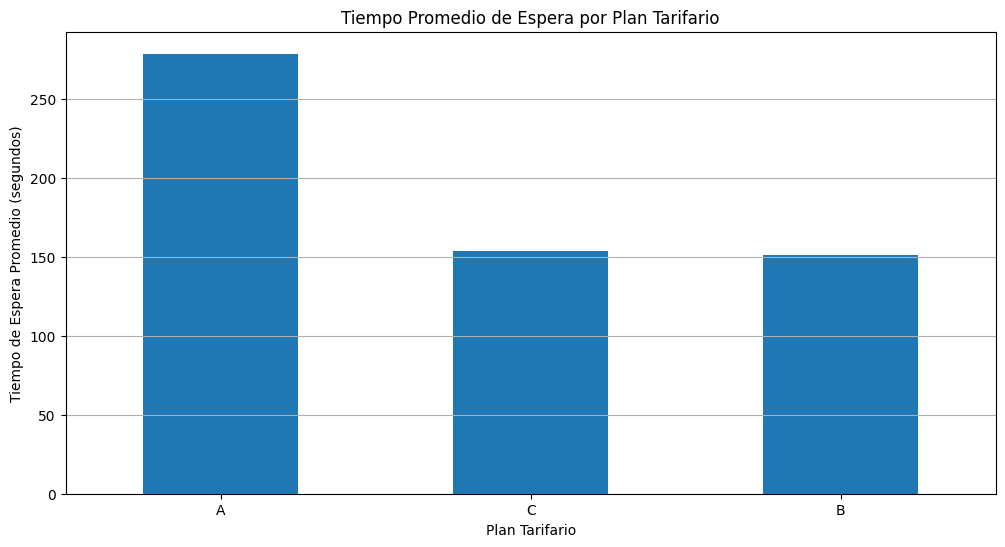

In [31]:
# Gráfico de tiempo de espera por plan tarifario
mean_waiting_time_by_plan = data.groupby('tariff_plan')['waiting_time'].mean().sort_values(ascending=False)

mean_waiting_time_by_plan.plot(kind='bar', figsize=(12, 6))

plt.title('Tiempo Promedio de Espera por Plan Tarifario')
plt.xlabel('Plan Tarifario')
plt.ylabel('Tiempo de Espera Promedio (segundos)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### 4. Pruebas de Hipótesis
**Descripción:** En esta sección, se realizarán pruebas estadísticas para validar si los 3 aspectos definidos como ineficacia de los operadores son significativamente diferentes entre los grupos de operadores "Eficaces" e "Ineficaces". Se considerarán los supuestos estadísticos de los datos para la correcta selección de la prueba.

#### 4.1. Clasificación de Operadores
Se creará una nueva columna en el conjunto de datos para clasificar a los operadores como 'Eficaces' o 'Ineficaces'.

Criterio de 'Ineficacia': Operadores con valores por encima del percentil 75 en la tasa de llamadas perdidas o en el tiempo promedio de espera.

Criterio de 'Eficacia': Operadores con valores por debajo del percentil 25 en la tasa de llamadas perdidas o en el tiempo promedio de espera.

In [32]:
operator_classification = data.groupby('operator_id').agg(
    missed_call_rate=('is_missed_call', 'sum'),
    mean_waiting_time=('waiting_time', 'mean')
)

# Calcula los percentiles 25 y 75 para cada métrica usando np.percentile
q1_missed = np.percentile(operator_classification['missed_call_rate'], 25)
q3_missed = np.percentile(operator_classification['missed_call_rate'], 75)
q1_waiting = np.percentile(operator_classification['mean_waiting_time'], 25)
q3_waiting = np.percentile(operator_classification['mean_waiting_time'], 75)

# Define las condiciones de clasificación
rules = [
    (operator_classification['missed_call_rate'] > q3_missed) | (operator_classification['mean_waiting_time'] > q3_waiting),
    (operator_classification['missed_call_rate'] < q1_missed) & (operator_classification['mean_waiting_time'] < q1_waiting)
]

# Define las categorías correspondientes
categories = ['Ineficaz', 'Eficaz']

# Crea la nueva columna 'operator_class' usando np.select
operator_classification['operator_class'] = np.select(rules, categories, default=np.nan)

# Elimina los operadores que no cumplen con los criterios y, por lo tanto, no fueron clasificados
operator_classification.dropna(subset=['operator_class'], inplace=True)

print(operator_classification['operator_class'].value_counts())
print("\nPrimeras 5 filas con la nueva clasificación:")
print(operator_classification.head())

nan         568
Ineficaz    419
Eficaz      105
Name: operator_class, dtype: int64

Primeras 5 filas con la nueva clasificación:
             missed_call_rate  mean_waiting_time operator_class
operator_id                                                    
879896                     47         104.914530       Ineficaz
879898                     89         457.696035       Ineficaz
880020                      6          14.000000            nan
880022                     29          53.971429       Ineficaz
880026                     87         121.978022       Ineficaz


**Nota Importante:** AL realizar la clasificación de los operadores, se observa que los criteros propuestos arrojan varios valores medios (determinados como nan), por lo que se toma la decisión de abordar la clasificación desde un distinto punto.

**Nuevas reglas de clasificación:**

Nuevo 'Criterio de Ineficacia': Si un operador tiene una tasa de llamadas perdidas o un tiempo de espera promedio por encima de la mediana del equipo (percentil 50).

Nuevo 'Criterio de Eficacia': Si un operador tiene una tasa de llamadas perdidas y un tiempo de espera promedio en o por debajo de la mediana del equipo (percentil 50).

In [33]:
new_operator_classification = data.groupby('operator_id').agg(
    missed_call_rate=('is_missed_call', 'sum'),
    mean_waiting_time=('waiting_time', 'mean')
)

median_missed = np.percentile(new_operator_classification['missed_call_rate'], 50)
median_waiting = np.percentile(new_operator_classification['mean_waiting_time'], 50)

print('Mediana de Llamadas perdidas:', median_missed)
print('Mediana de Tiempo de espera:', median_waiting)
print()

rules = [
    (new_operator_classification['missed_call_rate'] > median_missed) | 
    (new_operator_classification['mean_waiting_time'] > median_waiting)
]

# Define las categorías
categories = ['Ineficaz']

# Crea la nueva columna 'operator_class' usando np.select
# El valor por defecto es 'Eficaz' si la condición de 'Ineficaz' no se cumple
new_operator_classification['operator_class'] = np.select(rules, categories, default='Eficaz')

print(new_operator_classification['operator_class'].value_counts())
print("\nPrimeras 5 filas con la nueva clasificación:")
print(new_operator_classification.head())

Mediana de Llamadas perdidas: 5.0
Mediana de Tiempo de espera: 46.61904761904762

Ineficaz    674
Eficaz      418
Name: operator_class, dtype: int64

Primeras 5 filas con la nueva clasificación:
             missed_call_rate  mean_waiting_time operator_class
operator_id                                                    
879896                     47         104.914530       Ineficaz
879898                     89         457.696035       Ineficaz
880020                      6          14.000000       Ineficaz
880022                     29          53.971429       Ineficaz
880026                     87         121.978022       Ineficaz


#### 4.2. Preparación y Supuestos para las Pruebas Estadísticas
Antes de realizar las pruebas, se investigará la distribución y varianza de los datos en los grupos clasificados.

Verificación de normalidad: Se realizarán pruebas de normalidad (prueba de Shapiro-Wilk) para determinar si los datos se distribuyen de manera normal en cada grupo.

Verificación de homogeneidad de varianzas: Se utilizará la prueba de Levene para evaluar si las varianzas de los grupos son homogéneas.

- Si los datos son normales y las varianzas son iguales, las pruebas de hipótesis se realizarán por medio de t-test de Student.
- Si los datos son normales pero las varianzas no son iguales, las pruebas de hipótesis se realizarán por medio de t-test de Welch.
- Si los datos no son normales, las pruebas de hipótesis se realizarán por medio de la prueba de Mann-Whitney U.

In [34]:
# Verificación de Normalidad
# H0: Los datos tienen una distribución normal.
# H1: Los datos no tienen una distribución normal.
print("--- Verificación de Normalidad (Shapiro-Wilk) ---\n")

for metric in ['missed_call_rate', 'mean_waiting_time']:
    print(f"Resultados para la métrica: {metric}\n")

    efficaz_data = new_operator_classification[new_operator_classification['operator_class'] == 'Eficaz'][metric]
    ineficaz_data = new_operator_classification[new_operator_classification['operator_class'] == 'Ineficaz'][metric]
    
    if len(efficaz_data) >= 3:
        stat_e, p_value_e = shapiro(efficaz_data)
        print(f"  - Grupo 'Eficaz': p-value = {p_value_e:.4f}")
        if p_value_e < 0.05:
            print("    -> ¡Los datos NO son normales!")
        else:
            print("    -> Los datos podrían ser normales.")
    else:
        print("  - El grupo 'Eficaz' tiene muy pocos datos para la prueba.")

    if len(ineficaz_data) >= 3:
        stat_i, p_value_i = shapiro(ineficaz_data)
        print(f"  - Grupo 'Ineficaz': p-value = {p_value_i:.4f}")
        if p_value_i < 0.05:
            print("    -> ¡Los datos NO son normales!")
        else:
            print("    -> Los datos podrían ser normales.")
    else:
        print("  - El grupo 'Ineficaz' tiene muy pocos datos para la prueba.")

    print("\n" + "-"*40 + "\n")

--- Verificación de Normalidad (Shapiro-Wilk) ---

Resultados para la métrica: missed_call_rate

  - Grupo 'Eficaz': p-value = 0.0000
    -> ¡Los datos NO son normales!
  - Grupo 'Ineficaz': p-value = 0.0000
    -> ¡Los datos NO son normales!

----------------------------------------

Resultados para la métrica: mean_waiting_time

  - Grupo 'Eficaz': p-value = 0.0001
    -> ¡Los datos NO son normales!
  - Grupo 'Ineficaz': p-value = 0.0000
    -> ¡Los datos NO son normales!

----------------------------------------



<div class="alert alert-block alert-success">
<b>Celda [34]</b> <a class="tocSkip"></a><br>
Has aplicado correctamente la prueba de Shapiro-Wilk para verificar la normalidad de tus datos. Es importante confirmar que los supuestos estadísticos se cumplan antes de proceder con análisis más avanzados, ya que esto afecta la validez de las conclusiones que se puedan extraer.
</div>


In [35]:
# Verificación de Homogeneidad de Varianzas
# H0 : Las varianzas de los grupos son homogéneas.
# H1: Las varianzas de los grupos no son homogéneas.

print("--- Verificación de Homogeneidad (Prueba de Levene) ---\n")

for metric in ['missed_call_rate', 'mean_waiting_time']:
    print(f"Resultados para la métrica: {metric}\n")
    
    # Extraer los datos para cada grupo
    efficaz_data = operator_classification[operator_classification['operator_class'] == 'Eficaz'][metric]
    ineficaz_data = operator_classification[operator_classification['operator_class'] == 'Ineficaz'][metric]
    
    # Asegurarse de que los grupos tienen suficientes datos para la prueba
    if len(efficaz_data) < 2 or len(ineficaz_data) < 2:
        print("  - Al menos un grupo tiene muy pocos datos para la prueba de Levene.")
        continue

    stat, p_value = levene(efficaz_data, ineficaz_data)
    
    print(f"  - p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("    -> ¡Se rechaza la hipótesis de homogeneidad! Las varianzas NO son iguales.")
    else:
        print("    -> No se rechaza la hipótesis. Las varianzas PODRÍAN ser iguales.")
    print("\n" + "-"*40 + "\n")

--- Verificación de Homogeneidad (Prueba de Levene) ---

Resultados para la métrica: missed_call_rate

  - p-value = 0.0000
    -> ¡Se rechaza la hipótesis de homogeneidad! Las varianzas NO son iguales.

----------------------------------------

Resultados para la métrica: mean_waiting_time

  - p-value = 0.0000
    -> ¡Se rechaza la hipótesis de homogeneidad! Las varianzas NO son iguales.

----------------------------------------



**Conclusiones:**

1. Resultados de la Prueba Shapiro-Wilk (Verificación de Normalidad) 

En ambos grupos ('Eficaz' e 'Ineficaz') y para ambas métricas, el valor p es menor a 0.05. Esto significa que los datos no se distribuyen de manera normal.

2. Resultados de la Prueba Levene (Verificación de Homogeneidad de Varianzas)

El valor p es 0.0000 para ambas métricas, lo que nos indica que las varianzas de los grupos no son homogéneas.

3. Los datos no cumplen con los supuestos de normalidad ni homogeneidad, por lo tanto para la comprobación de hipótesis se utilizará la prueba de Mann-Whitney U.

#### 4.3. Prueba para la Tasa de Llamadas Perdidas
Hipótesis nula (H1): No hay una diferencia significativa en la tasa media de llamadas perdidas entre los operadores clasificados como 'Eficaces' e 'Ineficaces'.

Hipótesis alternativa (H0): La tasa media de llamadas perdidas de los operadores 'Ineficaces' es significativamente mayor que la de los operadores 'Eficaces'.

In [36]:
# Separar los datos en los dos grupos
efficaz_group = new_operator_classification[new_operator_classification['operator_class'] == 'Eficaz']
ineficaz_group = new_operator_classification[new_operator_classification['operator_class'] == 'Ineficaz']

print("--- Resultados de la Prueba de Mann-Whitney U ---\n")

# Prueba para la tasa de llamadas perdidas
stat_missed, p_value_missed = mannwhitneyu(
    efficaz_group['missed_call_rate'],
    ineficaz_group['missed_call_rate'],
    alternative='two-sided'
)

print(f"Métrica: Tasa de Llamadas Perdidas")
print(f"Estadístico de la prueba U: {stat_missed:.2f}")
print(f"Valor p: {p_value_missed:.4f}")

if p_value_missed < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula. La tasa media de llamadas perdidas de los operadores 'Ineficaces' es significativamente mayor que la de los operadores 'Eficaces'.")
else:
    print("Conclusión: No se rechaza la hipótesis nula. No hay una diferencia significativa en la tasa media de llamadas perdidas entre los operadores clasificados como 'Eficaces' e 'Ineficaces'.")

print("\n" + "-"*40 + "\n")

--- Resultados de la Prueba de Mann-Whitney U ---

Métrica: Tasa de Llamadas Perdidas
Estadístico de la prueba U: 24348.00
Valor p: 0.0000
Conclusión: Se rechaza la hipótesis nula. La tasa media de llamadas perdidas de los operadores 'Ineficaces' es significativamente mayor que la de los operadores 'Eficaces'.

----------------------------------------



<div class="alert alert-block alert-success">
<b>Celda [36]</b> <a class="tocSkip"></a><br>
La aplicación de la prueba de Mann-Whitney U es adecuada dado que los datos no son normales. Has interpretado correctamente los resultados, lo cual es crucial para extraer conclusiones válidas sobre las diferencias entre grupos en tu análisis.
</div>


#### 4.4. Prueba para el Tiempo de Espera
Hipótesis nula (H0): No hay una diferencia significativa en el tiempo medio de espera entre los operadores 'Eficaces' e 'Ineficaces'.

Hipótesis alternativa (H1): El tiempo medio de espera de los operadores 'Ineficaces' es significativamente mayor que el de los operadores 'Eficaces'.

In [37]:
# Prueba para el tiempo promedio de espera
stat_waiting, p_value_waiting = mannwhitneyu(
    efficaz_group['mean_waiting_time'],
    ineficaz_group['mean_waiting_time'],
    alternative='two-sided'
)

print(f"Métrica: Tiempo Promedio de Espera")
print(f"Estadístico de la prueba U: {stat_waiting:.2f}")
print(f"Valor p: {p_value_waiting:.4f}")

if p_value_waiting < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula. El tiempo medio de espera de los operadores 'Ineficaces' es significativamente mayor que el de los operadores 'Eficaces'.")
else:
    print("Conclusión: No se rechaza la hipótesis nula. No hay una diferencia significativa en el tiempo medio de espera entre los operadores 'Eficaces' e 'Ineficaces'.")

Métrica: Tiempo Promedio de Espera
Estadístico de la prueba U: 14518.00
Valor p: 0.0000
Conclusión: Se rechaza la hipótesis nula. El tiempo medio de espera de los operadores 'Ineficaces' es significativamente mayor que el de los operadores 'Eficaces'.


#### 4.5. Prueba para la Proporción de Llamadas Salientes
Hipótesis nula (H0): No hay una diferencia significativa en la proporción media de llamadas salientes entre los operadores 'Eficaces' e 'Ineficaces'.

Hipótesis alternativa (H1): La proporción media de llamadas salientes de los operadores 'Ineficaces' es significativamente menor que la de los operadores 'Eficaces'.

In [38]:
# 1. Agrupar los datos originales por operador para contar llamadas salientes y totales
calls_counts = data.groupby('operator_id').agg(
    total_calls=('call_duration', 'count'),
    outgoing_calls=('direction', lambda x: (x == 'out').sum())
)

# 2. Unir los conteos al DataFrame de clasificación
# Esto asegura que cada operador tenga su conteo de llamadas
new_operator_classification = new_operator_classification.merge(
    calls_counts,
    on='operator_id'
)

# 3. Separar los datos en grupos 'Eficaz' e 'Ineficaz'
efficaz_group = new_operator_classification[new_operator_classification['operator_class'] == 'Eficaz']
ineficaz_group = new_operator_classification[new_operator_classification['operator_class'] == 'Ineficaz']

# 4. Extraer el número de llamadas salientes y totales para cada grupo
count = [efficaz_group['outgoing_calls'].sum(), ineficaz_group['outgoing_calls'].sum()]
nobs = [efficaz_group['total_calls'].sum(), ineficaz_group['total_calls'].sum()]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"--- Prueba para la Proporción de Llamadas Salientes ---")
print(f"Estadístico Z: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula. La proporción media de llamadas salientes de los operadores 'Ineficaces' es significativamente menor que la de los operadores 'Eficaces'.")
else:
    print("Conclusión: No se rechaza la hipótesis nula. No hay una diferencia significativa en la proporción de llamadas salientes entre los operadores 'Eficaces' e 'Ineficaces.")

--- Prueba para la Proporción de Llamadas Salientes ---
Estadístico Z: -43.7994
Valor p: 1.0000
Conclusión: No se rechaza la hipótesis nula. No hay una diferencia significativa en la proporción de llamadas salientes entre los operadores 'Eficaces' e 'Ineficaces.


<div class="alert alert-block alert-warning">
<b>Celda [38]</b> <a class="tocSkip"></a><br>
Aunque el análisis de la proporción de llamadas salientes es interesante, el valor p indica que no hay diferencia significativa. Considera explorar otros factores que podrían influir en esta métrica para obtener una comprensión más profunda de los patrones de llamadas.
</div>


### Exportación de Dataframe para Tableau

In [39]:
from IPython.display import FileLink

file_name = 'datos_para_tableau.csv'
data.to_csv(file_name, index=False)

# 3. Muestra un enlace para descargar el archivo
print("El DataFrame ha sido exportado. Haz clic en el enlace de abajo para descargarlo:")
display(FileLink(file_name))

El DataFrame ha sido exportado. Haz clic en el enlace de abajo para descargarlo:


/app/datos_para_tableau.csv

### Parte 5. Conclusiones generales

**Conclusiones generales:**

1.	La tasa de llamadas perdidas y el tiempo promedio de espera pueden ser métricas adecuadas para determinar si un operador es eficiente o ineficiente.
2.	No se recomienda utilizar la cantidad de llamadas salientes como métrica para determinar si un operador es eficiente o ineficiente.
3.	Con base a este análisis, la empresa CallMeMaybe tiene una cantidad de 418 operadores (38.28%) de operadores eficientes y una cantidad de 674 (61.72%) de operadores ineficientes.

### Parte 6. Enlace a Presentación de resultados y Dashboard
##### **Enlace a presentación en PDF:**
https://drive.google.com/file/d/1spRIEAWwqD274pIpZaXKi2FtDipO_dbz/view?usp=sharing
https://drive.google.com/file/d/1x5RMhNcvbFo-_kAOV0xO359dIruGmeU8/view?usp=sharing

##### **Enlace a Dashboard en Tableau Public:**
https://public.tableau.com/views/Dashboard-Telecomunicaciones-EMS-DA-42/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Edgar! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Realizaste una exploración de datos inicial exhaustiva y bien documentada.<br>
• Convertiste adecuadamente los tipos de datos para facilitar el análisis.<br>
• Manejaste de manera efectiva los valores faltantes y duplicados.<br>
• Identificaste y eliminaste datos atípicos de forma precisa.<br>
• Utilizaste visualizaciones claras para comunicar tus hallazgos.<br>
• Aplicaste correctamente pruebas estadísticas para validar tus resultados.<br>
• Mostraste un buen entendimiento de los supuestos estadísticos necesarios.<br>
• Interpretaste adecuadamente los resultados de las pruebas de hipótesis.<br>
• Implementaste un enfoque estructurado para clasificar operadores.<br>
• Exportaste los datos de manera efectiva para su uso en herramientas externas.<br>
¡Felicidades!
</div>
